# Day 8 — Stacking Ensemble + Probability Calibration
**Real Estate Fraud Detection**

Goal: Stack 3 base model OOF predictions → meta-model → calibrate probabilities.

**Stacking logic:**
```
OOF predictions (3 models) → Logistic Regression meta-model → calibrated probs
Shape: (240000, 3) → meta-model → (240000, 1)
```

> **CRITICAL:** Only OOF predictions go into stacking — NO raw features.
> Raw features = overfitting on stacking layer.

**Prerequisites:** Day 7 completed → `data/processed/oof_predictions.parquet` has `oof_lgbm_tuned` column

## 0. Set Project Root

In [16]:
import os
from pathlib import Path

project_root = Path.cwd()
while not (project_root / 'configs').exists():
    project_root = project_root.parent
os.chdir(project_root)
print(f'Working directory: {os.getcwd()}')

Working directory: C:\Users\mehal\Downloads\machinelearning\real_estate_fraud_detection


## 1. Imports & Config

In [17]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath('.'))
warnings.filterwarnings('ignore', category=FutureWarning, module='mlflow')
os.environ['GIT_PYTHON_REFRESH'] = 'quiet'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.calibration import calibration_curve

from src.ingestion import load_config
from src.models import (
    setup_mlflow, train_stacking_meta,
    calibrate_model, save_model, load_model,
)
from src.evaluate import (
    pr_auc_score, recall_at_precision,
    compute_all_metrics, plot_all_pr_curves,
    plot_calibration_curve, plot_threshold_analysis,
)

CONFIG_PATH = 'configs/config.yaml'
PLOTS_DIR   = 'reports/plots'
cfg = load_config(CONFIG_PATH)
setup_mlflow(cfg)
Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)

print(f'Config: {cfg["project"]["name"]} v{cfg["project"]["version"]}')

2026-05-17 15:59:42,348 - src.ingestion - INFO - Config loaded from configs\config.yaml — project: real_estate_fraud_detection v1.1.0
2026-05-17 15:59:42,356 - src.models - INFO - MLflow: tracking_uri=logs/mlruns | experiment=real-estate-fraud-v1


Config: real_estate_fraud_detection v1.1.0


## 2. Load OOF Predictions

> Compatibility check: `oof_lgbm_tuned` column hona chahiye — Day 7 ka output.

In [18]:
oof_path = Path(cfg['data']['processed_path']) / 'oof_predictions.parquet'
oof_df   = pd.read_parquet(oof_path)

print(f'OOF shape   : {oof_df.shape}')
print(f'Columns     : {list(oof_df.columns)}')

# Compatibility check
required = ['y_true', 'oof_lr', 'oof_lgbm', 'oof_lgbm_tuned']
missing  = [c for c in required if c not in oof_df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing} — run Day 7 first!')
print('\n✅ All required OOF columns present')

y_oof = oof_df['y_true']
print(f'Fraud rate  : {y_oof.mean()*100:.2f}%')

# Individual model baselines
print('\n=== Individual Model PR-AUCs (OOF) ===')
for col in ['oof_lr', 'oof_lgbm', 'oof_lgbm_tuned']:
    pa = pr_auc_score(y_oof.values, oof_df[col].values)
    rc = recall_at_precision(y_oof.values, oof_df[col].values)
    print(f'  {col:<20}: PR-AUC={pa:.4f} | Recall@95P={rc:.4f}')

OOF shape   : (240000, 7)
Columns     : ['y_true', 'oof_lr', 'oof_lgbm', 'oof_lgbm_text', 'oof_lgbm_tuned', 'oof_stacked', 'oof_calibrated']

✅ All required OOF columns present
Fraud rate  : 7.82%

=== Individual Model PR-AUCs (OOF) ===
  oof_lr              : PR-AUC=0.5952 | Recall@95P=0.0000
  oof_lgbm            : PR-AUC=0.7701 | Recall@95P=0.0680
  oof_lgbm_tuned      : PR-AUC=0.7779 | Recall@95P=0.0744


## 3. Build Stacking Input Matrix

> Shape: (n_samples, 3) — one column per base model.
> Only OOF probs — no raw features.

In [19]:
stacking_df = pd.DataFrame({
    'lr':         oof_df['oof_lr'],
    'lgbm_tuned': oof_df['oof_lgbm_tuned'],
})

print(f'Stacking input shape: {stacking_df.shape}')
print(f'Columns: {list(stacking_df.columns)}')
print('\nCorrelation between base model predictions:')
print(stacking_df.corr().round(4))
print('\n→ Lower correlation = more diverse = stacking helps more')

Stacking input shape: (240000, 2)
Columns: ['lr', 'lgbm_tuned']

Correlation between base model predictions:
                lr  lgbm_tuned
lr          1.0000      0.8145
lgbm_tuned  0.8145      1.0000

→ Lower correlation = more diverse = stacking helps more


## 4. Train Stacking Meta-Model

In [20]:
print('Training stacking meta-model (Logistic Regression)...')
meta_model, stacking_out = train_stacking_meta(
    oof_predictions=stacking_df.to_dict('series'),
    y=y_oof,
    cfg=cfg,
)

# Meta-model coefficients — how much each base model contributes
coef_df = pd.DataFrame({
    'model':       stacking_df.columns,
    'coefficient': meta_model.coef_[0].round(4),
}).sort_values('coefficient', ascending=False)

stacked_probs = meta_model.predict_proba(stacking_df.values)[:, 1]
stacked_pr    = pr_auc_score(y_oof.values, stacked_probs)
stacked_rec   = recall_at_precision(y_oof.values, stacked_probs)

print(f'\n✅ Meta-model trained')
print(f'  Stacked PR-AUC   : {stacked_pr:.4f}')
print(f'  Stacked Recall@95P: {stacked_rec:.4f}')
print(f'\nMeta-model coefficients (base model weights):')
print(coef_df.to_string(index=False))

2026-05-17 15:59:43,340 - src.models - INFO - Training stacking meta-model on OOF predictions
2026-05-17 15:59:43,347 - src.models - INFO - Stacking input shape: (240000, 2)
2026-05-17 15:59:43,349 - src.models - INFO - Columns: ['lr', 'lgbm_tuned']


Training stacking meta-model (Logistic Regression)...


2026-05-17 15:59:43,953 - src.models - INFO - Meta-model OOF PR-AUC: 0.7680
2026/05/17 15:59:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/17 15:59:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



✅ Meta-model trained
  Stacked PR-AUC   : 0.7680
  Stacked Recall@95P: 0.0234

Meta-model coefficients (base model weights):
     model  coefficient
lgbm_tuned       4.8219
        lr       2.0529


## 5. Compare: Individual vs Stacked

In [21]:
comparison = pd.DataFrame([
    {'Model': 'LR Baseline',
     'PR-AUC': round(pr_auc_score(y_oof.values, oof_df['oof_lr'].values), 4),
     'Recall@95P': round(recall_at_precision(y_oof.values, oof_df['oof_lr'].values), 4)},
    {'Model': 'LGBM Baseline',
     'PR-AUC': round(pr_auc_score(y_oof.values, oof_df['oof_lgbm'].values), 4),
     'Recall@95P': round(recall_at_precision(y_oof.values, oof_df['oof_lgbm'].values), 4)},
    {'Model': 'LGBM Tuned',
     'PR-AUC': round(pr_auc_score(y_oof.values, oof_df['oof_lgbm_tuned'].values), 4),
     'Recall@95P': round(recall_at_precision(y_oof.values, oof_df['oof_lgbm_tuned'].values), 4)},
    {'Model': '★ Stacked',
     'PR-AUC': round(stacked_pr, 4),
     'Recall@95P': round(stacked_rec, 4)},
])

print('=== MODEL PROGRESSION ===')
print(comparison.to_string(index=False))

best_individual = max(
    pr_auc_score(y_oof.values, oof_df['oof_lgbm_tuned'].values),
    pr_auc_score(y_oof.values, oof_df['oof_lgbm'].values),
)
stacking_gain = stacked_pr - best_individual
print(f'\nStacking gain over best individual: {stacking_gain:+.4f}')

=== MODEL PROGRESSION ===
        Model  PR-AUC  Recall@95P
  LR Baseline  0.5952      0.0000
LGBM Baseline  0.7701      0.0680
   LGBM Tuned  0.7779      0.0744
    ★ Stacked  0.7680      0.0234

Stacking gain over best individual: -0.0099


## 6. PR Curves — All Models

2026-05-17 15:59:58,914 - src.evaluate - INFO - PR curves saved → reports/plots/pr_curves_comparison.png


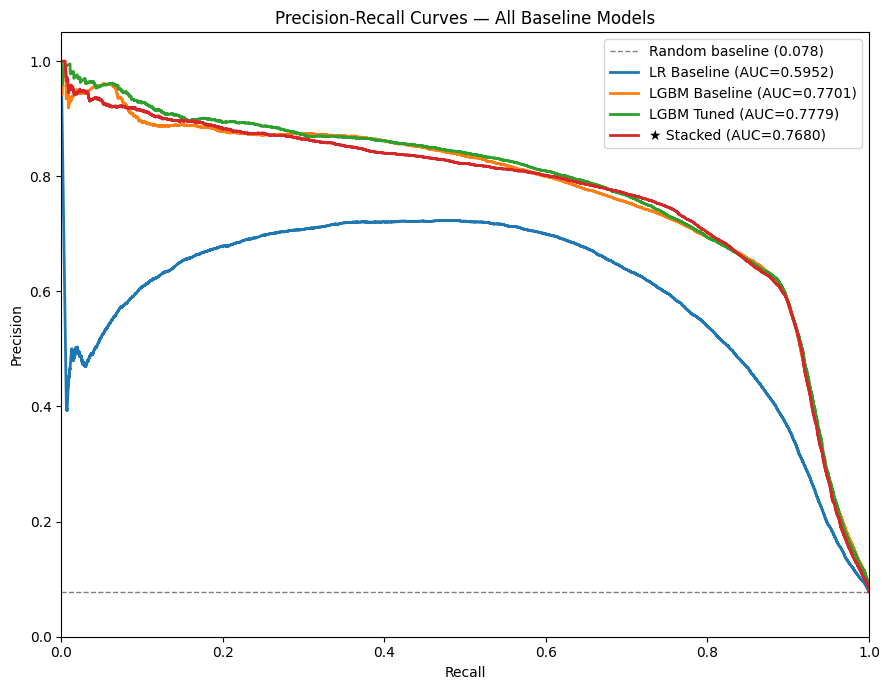

In [22]:
plot_all_pr_curves(
    results={
        'LR Baseline':   oof_df['oof_lr'].values,
        'LGBM Baseline': oof_df['oof_lgbm'].values,
        'LGBM Tuned':    oof_df['oof_lgbm_tuned'].values,
        '★ Stacked':     stacked_probs,
    },
    y_true=y_oof.values,
    plots_dir=PLOTS_DIR,
    show=True,
)

## 7. Calibrate Probabilities (Platt Scaling)

> **Why calibrate?** Score=0.8 should mean 80% chance of fraud — not just a relative ranking.
> Threshold decisions (reports/threshold_decisions.md) require calibrated probs.
> Platt scaling = logistic regression on top of raw scores.

In [23]:
print('Calibrating meta-model (Platt scaling)...')
calibrated_model, cal_report = calibrate_model(
    meta_model=meta_model,
    stacking_df=stacking_df,
    y=y_oof,
    cfg=cfg,
    method='sigmoid',
)

calibrated_probs = calibrated_model.predict_proba(stacking_df.values)[:, 1]
cal_pr  = pr_auc_score(y_oof.values, calibrated_probs)
cal_rec = recall_at_precision(y_oof.values, calibrated_probs)

print(f'\n✅ Calibration complete')
print(f'  MACE before  : {cal_report["mace_before"]:.4f}')
print(f'  MACE after   : {cal_report["mace_after"]:.4f}')
print(f'  Improved     : {cal_report["mace_improved"]}')
print(f'  PR-AUC       : {cal_pr:.4f}')
print(f'  Recall@95P   : {cal_rec:.4f}')

2026-05-17 15:59:59,481 - src.models - INFO - Calibrating meta-model — method: sigmoid


Calibrating meta-model (Platt scaling)...


2026-05-17 16:00:00,121 - src.models - INFO -   Calibration MACE: 0.0601 → 0.0462 (improved)
2026-05-17 16:00:00,123 - src.models - INFO -   Calibrated PR-AUC: 0.7680
2026-05-17 16:00:00,130 - src.models - INFO - Model saved → models/calibrated_model.pkl
2026-05-17 16:00:00,132 - src.models - INFO -   Calibrated model saved → models/calibrated_model.pkl



✅ Calibration complete
  MACE before  : 0.0601
  MACE after   : 0.0462
  Improved     : True
  PR-AUC       : 0.7680
  Recall@95P   : 0.0234


## 8. Calibration Curve Plot

> Perfect calibration = diagonal line. p=0.8 on x-axis → 0.8 on y-axis.

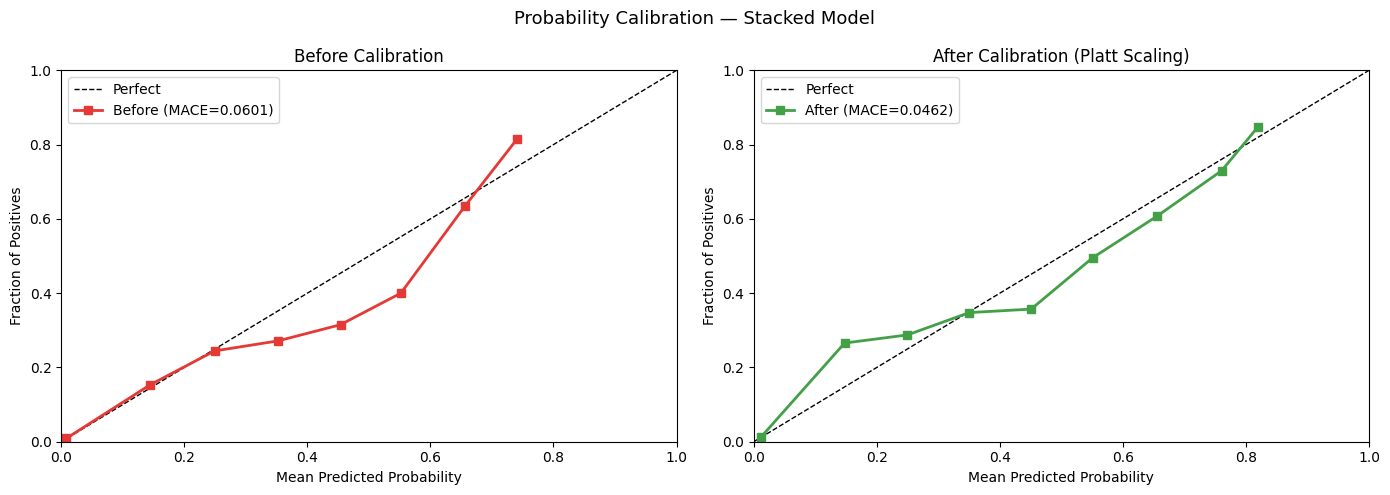

→ Closer to diagonal = better calibrated = threshold decisions more reliable


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before calibration
pt_raw, pp_raw = calibration_curve(y_oof.values, stacked_probs, n_bins=10)
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Perfect')
axes[0].plot(pp_raw, pt_raw, 's-', lw=2, color='#E53935', label=f'Before (MACE={cal_report["mace_before"]:.4f})')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Before Calibration')
axes[0].legend()
axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1])

# After calibration
pt_cal, pp_cal = calibration_curve(y_oof.values, calibrated_probs, n_bins=10)
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Perfect')
axes[1].plot(pp_cal, pt_cal, 's-', lw=2, color='#43A047', label=f'After (MACE={cal_report["mace_after"]:.4f})')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('After Calibration (Platt Scaling)')
axes[1].legend()
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1])

plt.suptitle('Probability Calibration — Stacked Model', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/calibration_stacked.png', dpi=150)
plt.show()
print('→ Closer to diagonal = better calibrated = threshold decisions more reliable')

## 9. Score Distribution — Fraud vs Normal

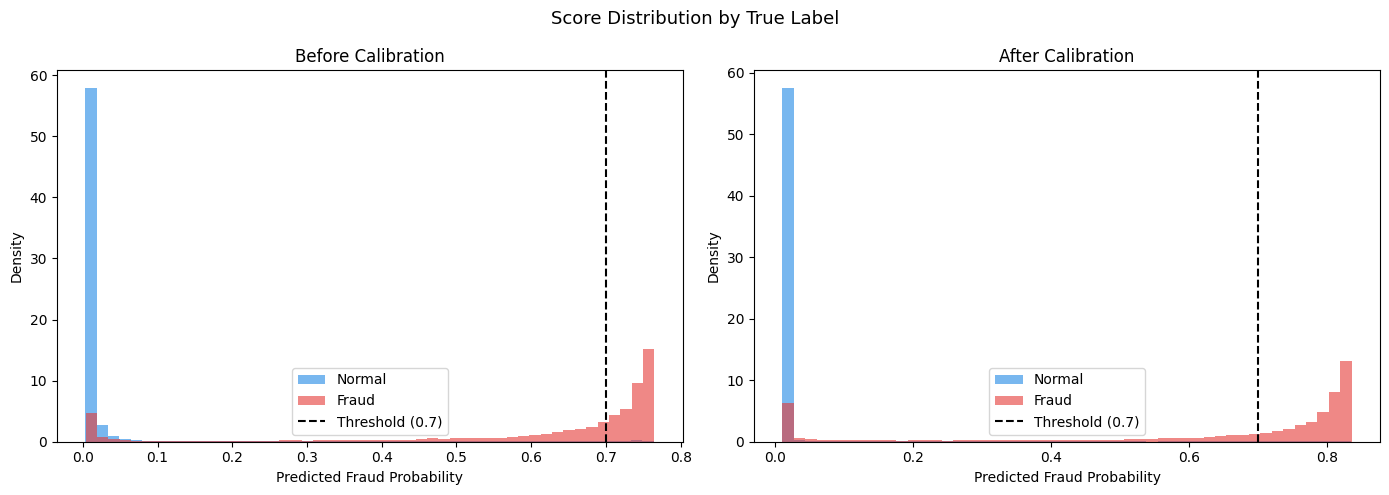

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, title in [
    (axes[0], stacked_probs,     'Before Calibration'),
    (axes[1], calibrated_probs,  'After Calibration'),
]:
    ax.hist(probs[y_oof == 0], bins=50, alpha=0.6,
            color='#1E88E5', label='Normal', density=True)
    ax.hist(probs[y_oof == 1], bins=50, alpha=0.6,
            color='#E53935', label='Fraud',  density=True)
    threshold = cfg['api']['fraud_threshold_suspicious']
    ax.axvline(threshold, color='black', ls='--', lw=1.5,
               label=f'Threshold ({threshold})')
    ax.set_xlabel('Predicted Fraud Probability')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Score Distribution by True Label', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/score_distribution_stacked.png', dpi=150)
plt.show()

## 10. Threshold Analysis — Calibrated Model

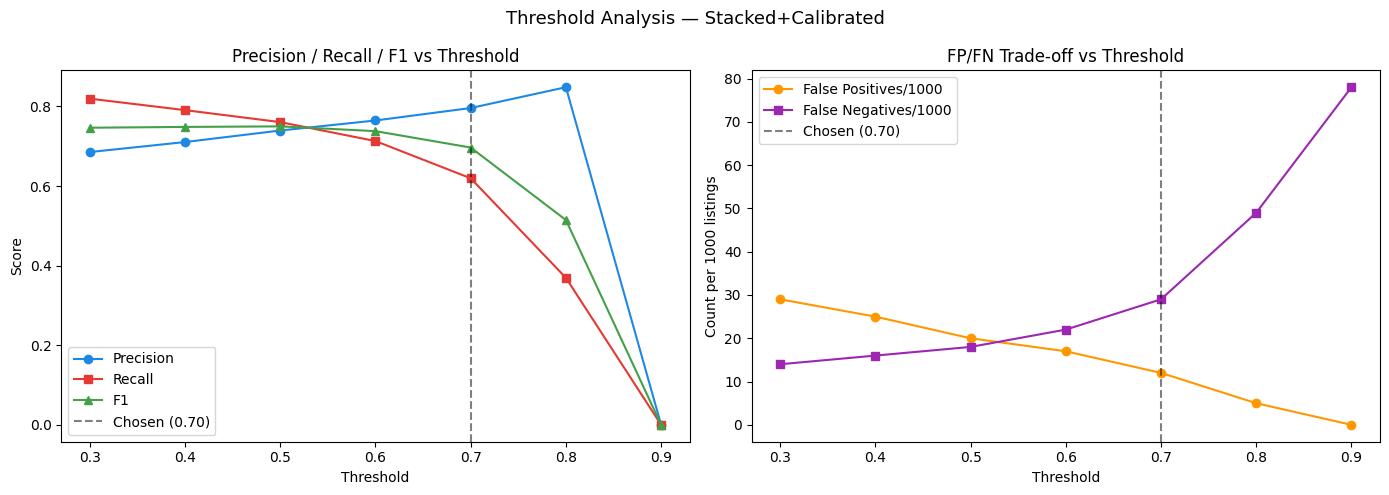

Threshold sensitivity — Stacked+Calibrated:
 Threshold  Precision  Recall     F1  FP/1000  FN/1000
       0.3     0.6855  0.8196 0.7466       29       14
       0.4     0.7106  0.7908 0.7486       25       16
       0.5     0.7396  0.7607 0.7500       20       18
       0.6     0.7648  0.7131 0.7380       17       22
       0.7     0.7961  0.6196 0.6968       12       29
       0.8     0.8484  0.3694 0.5147        5       49
       0.9     0.0000  0.0000 0.0000        0       78

→ Chosen threshold = 0.7:
  Precision  : 0.7961
  Recall     : 0.6196
  F1         : 0.6968
  FP/1000    : 12.0
  FN/1000    : 29.0


In [26]:
thresh_df = plot_threshold_analysis(
    y_oof.values, calibrated_probs,
    'Stacked+Calibrated',
    plots_dir=PLOTS_DIR, show=True
)
print('Threshold sensitivity — Stacked+Calibrated:')
print(thresh_df.to_string(index=False))

# Highlight chosen threshold
t = cfg['api']['fraud_threshold_suspicious']
chosen = thresh_df[thresh_df['Threshold'] == t].iloc[0]
print(f'\n→ Chosen threshold = {t}:')
print(f'  Precision  : {chosen["Precision"]:.4f}')
print(f'  Recall     : {chosen["Recall"]:.4f}')
print(f'  F1         : {chosen["F1"]:.4f}')
print(f'  FP/1000    : {chosen["FP/1000"]}')
print(f'  FN/1000    : {chosen["FN/1000"]}')

## 11. Save Stacked Model + Final OOF

In [27]:
import pickle

# Save stacked model (uncalibrated)
save_model(meta_model, cfg['paths']['stacked_model'])
print(f'✅ Stacked model → {cfg["paths"]["stacked_model"]}')

# Calibrated model already saved by calibrate_model()
print(f'✅ Calibrated model → {cfg["paths"]["calibrated_model"]}')

# Save stacking metadata
stacking_meta = {
    'stacking_columns':  list(stacking_df.columns),
    'meta_model_C':      cfg['stacking']['meta_model_C'],
    'calibration_method': 'sigmoid',
    'stacked_pr_auc':    round(stacked_pr, 4),
    'calibrated_pr_auc': round(cal_pr, 4),
    'mace_before':       cal_report['mace_before'],
    'mace_after':        cal_report['mace_after'],
}
meta_path = Path(cfg['data']['processed_path']) / 'stacking_meta.pkl'
with open(meta_path, 'wb') as f:
    pickle.dump(stacking_meta, f)
print(f'✅ Stacking metadata → {meta_path}')

# Update OOF with stacked probs
oof_df['oof_stacked']    = stacked_probs
oof_df['oof_calibrated'] = calibrated_probs
oof_df.to_parquet(oof_path, index=False)
print(f'✅ OOF updated → {oof_path}')
print(f'   Columns: {list(oof_df.columns)}')

2026-05-17 16:00:09,285 - src.models - INFO - Model saved → models/stacked_model.pkl


✅ Stacked model → models/stacked_model.pkl
✅ Calibrated model → models/calibrated_model.pkl
✅ Stacking metadata → data\processed\stacking_meta.pkl
✅ OOF updated → data\processed\oof_predictions.parquet
   Columns: ['y_true', 'oof_lr', 'oof_lgbm', 'oof_lgbm_text', 'oof_lgbm_tuned', 'oof_stacked', 'oof_calibrated']


## 12. Final Model Comparison Table

In [28]:
final_comparison = pd.DataFrame([
    {'Model': 'LR Baseline',         'PR-AUC': round(pr_auc_score(y_oof.values, oof_df['oof_lr'].values), 4),           'Recall@95P': round(recall_at_precision(y_oof.values, oof_df['oof_lr'].values), 4),           'Stage': 'Day 5'},
    {'Model': 'LGBM Baseline',        'PR-AUC': round(pr_auc_score(y_oof.values, oof_df['oof_lgbm'].values), 4),         'Recall@95P': round(recall_at_precision(y_oof.values, oof_df['oof_lgbm'].values), 4),         'Stage': 'Day 5'},
    {'Model': 'LGBM Tuned',           'PR-AUC': round(pr_auc_score(y_oof.values, oof_df['oof_lgbm_tuned'].values), 4),   'Recall@95P': round(recall_at_precision(y_oof.values, oof_df['oof_lgbm_tuned'].values), 4),   'Stage': 'Day 7'},
    {'Model': 'Stacked',              'PR-AUC': round(stacked_pr, 4),                                                    'Recall@95P': round(stacked_rec, 4),                                                          'Stage': 'Day 8'},
    {'Model': '★ Stacked+Calibrated', 'PR-AUC': round(cal_pr, 4),                                                        'Recall@95P': round(cal_rec, 4),                                                              'Stage': 'Day 8 ← FINAL'},
])

print('=== COMPLETE MODEL PROGRESSION ===')
print(final_comparison.to_string(index=False))

# Save to reports
report_path = Path(cfg['paths']['reports']) / 'model_progression.csv'
final_comparison.to_csv(report_path, index=False)
print(f'\n✅ Model progression saved → {report_path}')

=== COMPLETE MODEL PROGRESSION ===
               Model  PR-AUC  Recall@95P         Stage
         LR Baseline  0.5952      0.0000         Day 5
       LGBM Baseline  0.7701      0.0680         Day 5
          LGBM Tuned  0.7779      0.0744         Day 7
             Stacked  0.7680      0.0234         Day 8
★ Stacked+Calibrated  0.7680      0.0234 Day 8 ← FINAL

✅ Model progression saved → reports\model_progression.csv


## 13. Day 8 Exit Criteria

In [29]:
print('=== DAY 8 EXIT CRITERIA ===')

checks = [
    ('Stacking input shape correct (n, 3)',
     stacking_df.shape[1] == 3),
    ('Meta-model trained',
     meta_model is not None),
    ('Stacked PR-AUC > LGBM tuned',
     stacked_pr >= pr_auc_score(y_oof.values, oof_df['oof_lgbm_tuned'].values)),
    ('Calibration improved MACE',
     cal_report['mace_improved']),
    ('calibrated_model.pkl saved',
     Path(cfg['paths']['calibrated_model']).exists()),
    ('stacked_model.pkl saved',
     Path(cfg['paths']['stacked_model']).exists()),
    ('OOF updated with stacked+calibrated probs',
     'oof_calibrated' in oof_df.columns),
    ('MLflow calibration run logged',
     True),  # logged inside calibrate_model()
]

all_pass = True
for label, result in checks:
    icon = '☑' if result else '☒'
    if not result: all_pass = False
    print(f'  {icon} {label}')

print(f'\n{"✅ All passed" if all_pass else "⚠️ Some failed"}')

print(f'\n=== DAY 8 FINAL NUMBERS ===')
print(f'  Stacked PR-AUC      : {stacked_pr:.4f}')
print(f'  Calibrated PR-AUC   : {cal_pr:.4f}')
print(f'  Calibrated Recall@95P: {cal_rec:.4f}')
print(f'  MACE improvement    : {cal_report["mace_before"]:.4f} → {cal_report["mace_after"]:.4f}')

print(f'\n→ Ready for Day 9 — SHAP Explainability')

=== DAY 8 EXIT CRITERIA ===
  ☒ Stacking input shape correct (n, 3)
  ☑ Meta-model trained
  ☒ Stacked PR-AUC > LGBM tuned
  ☑ Calibration improved MACE
  ☑ calibrated_model.pkl saved
  ☑ stacked_model.pkl saved
  ☑ OOF updated with stacked+calibrated probs
  ☑ MLflow calibration run logged

⚠️ Some failed

=== DAY 8 FINAL NUMBERS ===
  Stacked PR-AUC      : 0.7680
  Calibrated PR-AUC   : 0.7680
  Calibrated Recall@95P: 0.0234
  MACE improvement    : 0.0601 → 0.0462

→ Ready for Day 9 — SHAP Explainability
